# TP1 — Le réseau du métro de Montréal
## Carnet, graphes, Dijkstra — et un premier modèle

**Nom :** _Xuan Wang_ &nbsp;&nbsp;&nbsp; **Coéquipier :** _Aucun_ &nbsp;&nbsp;&nbsp; **Groupe :** _Aucun_

---

Ce TP se fait **seul ou en équipe de 2**. Une équipe remet **un seul carnet** et
indique à la fin qui a fait quoi.

**Chaque question, y compris les questions de code, se termine par une cellule
d'observation en Markdown.** Écrivez-y ce que vous constatez, en phrases complètes,
en français. Une cellule d'observation laissée telle quelle vaut 0 pour la question.

Avant de remettre : **Kernel → Redémarrer et tout exécuter**.

## Partie 2 — Charger et explorer le réseau

Le fichier `donnees/metro_montreal.csv` contient une ligne par lien entre deux
stations voisines, avec la durée approximative en minutes. Le fichier
`donnees/stations.csv` donne la ligne de chaque station.

In [6]:
import csv

reseau = {}

with open("donnees/metro_montreal.csv", encoding="utf-8") as fichier: 
    for ligne in csv.DictReader(fichier):
        a = ligne["station_a"]
        b = ligne["station_b"]
        minutes = int(ligne["minutes"])
        reseau.setdefault(a, []).append((b, minutes)) 
        reseau.setdefault(b, []).append((a, minutes))

infos_station = {}
with open("donnees/stations.csv", encoding="utf-8") as fichier:
    for ligne in csv.DictReader(fichier):
        infos_station[ligne["station"]] = ligne

print(len(reseau), "stations")


def voisins(reseau, station):
    resultat = []

    for nom, minutes in reseau[station]:
        resultat.append(nom)

    return resultat


def temps(reseau, a, b):
    for nom, minutes in reseau[a]:
        if nom == b:
            return minutes
    return None

68 stations


**Q2.1** — Affichez le nombre de stations et le nombre de **liens**.

In [7]:
# Q2.1
nombre_stations = len(reseau)
nombre_liens = sum(len(voisins) for voisins in reseau.values()) // 2

print("Nombre de stations :", nombre_stations)
print("Nombre de liens :", nombre_liens)

Nombre de stations : 68
Nombre de liens : 69


> **Observation — obligatoire.** Comparez vos deux nombres. Qu'est-ce que leur écart vous dit sur la forme du réseau ?
>
Si toutes les stations étaient situées sur une seule ligne, le nombre de liens devrait être égal au nombre de stations moins un. Or, les résultats montrent que 68 stations sont reliées par 69 liens. Le nombre de liens est donc légèrement supérieur au nombre de stations, ce qui indique qu’il existe des connexions supplémentaires dans le réseau, avec plusieurs lignes de métro et possiblement des structures en boucle.

**Q2.2** — Trouvez la ou les stations qui ont le plus de voisins, puis la liste des
**terminus**.

In [17]:
# Q2.2
nombre_voisins = {}

for station in reseau:
    nombre_voisins[station] = len(voisins(reseau, station))

maximum = max(nombre_voisins.values())
station_maximum = [station for station, 
                   nombre in nombre_voisins.items()
                   if nombre == maximum]
print(maximum)
print(f"Les stations qui ont le plus de voisins sont : {', '.join(station_maximum)}.")

terminals = []
for station in reseau:
    if len(voisins(reseau,station)) == 1:
        terminals.append(station)
print (terminals)



5
Les stations qui ont le plus de voisins sont : Berri-UQAM.
['Angrignon', 'Honore-Beaugrand', 'Cote-Vertu', 'Montmorency', 'Saint-Michel', 'Longueuil']


> **Observation — obligatoire.** Pourquoi ces stations-là ? Expliquez ce que leur nombre de voisins traduit dans le vrai réseau.
>
> *Berri-UQAM est la station qui a le plus de voisins, avec 5 voisins. Cela traduit son rôle important comme station de connexion dans le réseau. Les six terminus n'ont qu'un seul voisin, car ils se trouvent à l'extrémité d'une ligne de métro.*

**Q2.3** — Comptez combien de tronçons durent 1, 2 et 3 minutes.

In [19]:
# Q2.3
compteur = {
    1: 0,
    2: 0,
    3: 0
}

for station in reseau:
    for nom, minutes in reseau[station]:
        if minutes in compteur:
            compteur[minutes] += 1

for minutes in compteur:
    compteur[minutes] //= 2

print(compteur)

{1: 13, 2: 37, 3: 19}


> **Observation — obligatoire.** Quelle durée domine, et dans quelle proportion ? Gardez ce chiffre : il servira à la partie 5.
>
> *Les tronçons de 2 minutes sont les plus nombreux, avec 37 tronçons sur 69, soit environ 53,6 % du réseau. La durée de 2 minutes est donc la durée dominante parmi les tronçons.*

## Partie 3 — Le parcours en largeur, et son arbre

**Q3.1** — Complétez `bfs(reseau, depart)`. Il rend `distance` (en nombre d'arrêts)
et `precedent`.

In [26]:
from collections import deque

def bfs(reseau, depart):
    distance = {depart: 0}
    precedent = {}
    file = deque([depart])
    while file:
        station = file.popleft()
        for suivante in voisins(reseau, station):
                if suivante not in distance:
                    distance[suivante] = distance[station] + 1
                    precedent[suivante] = station
                    file.append(suivante)
    return distance, precedent

distance, precedent = bfs(reseau, "Angrignon")
print(distance)
print(precedent)

{'Angrignon': 0, 'Monk': 1, 'Jolicoeur': 2, 'Verdun': 3, "De l'Eglise": 4, 'LaSalle': 5, 'Charlevoix': 6, 'Lionel-Groulx': 7, 'Atwater': 8, 'Place-Saint-Henri': 8, 'Georges-Vanier': 8, 'Guy-Concordia': 9, 'Vendome': 9, "Lucien-L'Allier": 9, 'Peel': 10, 'Villa-Maria': 10, 'Bonaventure': 10, 'McGill': 11, 'Snowdon': 11, 'Square-Victoria': 11, 'Place-des-Arts': 12, 'Cote-Sainte-Catherine': 12, 'Cote-des-Neiges': 12, "Place-d'Armes": 12, 'Saint-Laurent': 13, 'Plamondon': 13, 'Universite-de-Montreal': 13, 'Champ-de-Mars': 13, 'Berri-UQAM': 14, 'Namur': 14, 'Edouard-Montpetit': 14, 'Beaudry': 15, 'Sherbrooke': 15, 'Jean-Drapeau': 15, 'De la Savane': 15, 'Outremont': 15, 'Papineau': 16, 'Mont-Royal': 16, 'Longueuil': 16, 'Du College': 16, 'Acadie': 16, 'Frontenac': 17, 'Laurier': 17, 'Cote-Vertu': 17, 'Parc': 17, 'Prefontaine': 18, 'Rosemont': 18, 'De Castelnau': 18, 'Joliette': 19, 'Beaubien': 19, 'Jean-Talon': 19, 'Pie-IX': 20, 'Jarry': 20, 'Fabre': 20, 'Viau': 21, 'Cremazie': 21, "D'Ibervi

> **Observation — obligatoire.** Décrivez en vos mots ce que contient `precedent` à la fin, et à quoi il servira.
>
> Le dictionnaire `precedent` indique, pour chaque station atteinte, la station par laquelle elle a été découverte. Il servira ensuite à reconstruire le chemin entre la station de départ et une station d'arrivée.

**Q3.2** — Lancez le BFS depuis la station de votre choix. Combien de stations sont
atteintes ? Laquelle est la plus loin, en nombre d'arrêts ?

In [33]:
# Q3.2
station_commence = "Berri-UQAM"
distance, precedent = bfs(reseau, station_commence)

nombre_stations = len(distance)
distance_max = max(distance.values())

stations_plus_loin = [
    station
    for station, nombre in distance.items()
    if nombre == distance_max
]

print(f"Nombre de stations atteintes de {station_commence}: {nombre_stations}")

for station in stations_plus_loin:
    print(f"{station} est la station la plus loin d'Angrignon en nombre d'arrêts, avec {distance[station]} arrêts.")


Nombre de stations atteintes de Berri-UQAM: 68
Cote-Vertu est la station la plus loin d'Angrignon en nombre d'arrêts, avec 17 arrêts.


> **Observation — obligatoire.** Le nombre de stations atteintes vous apprend quelque chose sur le réseau : quoi ? Et la station la plus loin vous surprend-elle ?
>
> Les 68 stations sont atteignables depuis Berri-UQAM, ce qui montre que le réseau est bien connecté et qu’il est possible de se déplacer entre toutes les stations. Les stations Cote-Vertu est le plus éloignées d’Berri-UQAM avec 17 arrêts, car elles se trouvent à l’extrémité opposée du réseau et aussi les terminals.

**Q3.3** — Dessinez l'**arbre de parcours** (les 3 premiers niveaux) avec
`graphviz`.

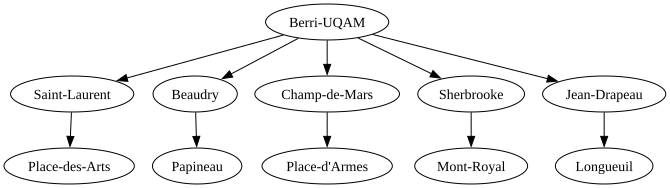

In [34]:
from graphviz import Digraph

# Q3.3
graphe = Digraph()

for station in distance:
    if distance[station] <= 2:
        graphe.node(station)

for station in precedent:
    if station in distance and distance[station] <= 2:
        graphe.edge(precedent[station], station)

graphe


In [35]:
for station in distance:
    if distance[station] <= 2:
        print(station, "→", voisins(reseau, station))

Berri-UQAM → ['Saint-Laurent', 'Beaudry', 'Champ-de-Mars', 'Sherbrooke', 'Jean-Drapeau']
Saint-Laurent → ['Place-des-Arts', 'Berri-UQAM']
Beaudry → ['Berri-UQAM', 'Papineau']
Champ-de-Mars → ["Place-d'Armes", 'Berri-UQAM']
Sherbrooke → ['Berri-UQAM', 'Mont-Royal']
Jean-Drapeau → ['Berri-UQAM', 'Longueuil']
Place-des-Arts → ['McGill', 'Saint-Laurent']
Papineau → ['Beaudry', 'Frontenac']
Place-d'Armes → ['Square-Victoria', 'Champ-de-Mars']
Mont-Royal → ['Sherbrooke', 'Laurier']
Longueuil → ['Jean-Drapeau']


> **Observation — obligatoire.** Le réseau n'est pas un arbre, et pourtant votre dessin en est un. Expliquez pourquoi.
>
> *Le réseau du métro n’est pas un arbre, car il peut contenir des cycles et plusieurs chemins pour rejoindre une station.Par contre, le BFS construit un arbre de parcours : chaque station est visitée une seule fois et possède un seul parent (sauf la station de départ, Berri-UQAM).Le dessin représente donc uniquement les liens utilisés par le BFS pour découvrir les stations, et non tous les liens du réseau.*

## Partie 4 — Dijkstra, en minutes

**Q4.1** — Complétez `plus_petite_case`, `relacher` et `dijkstra`.

In [37]:
INFINI = 9999

def plus_petite_case(distance, barres):
    record = INFINI
    choisie = None
    for station in distance:
        if station in barres:
            continue
        if distance[station] < record:
            record = distance[station]
            choisie = station
    return choisie


def relacher(distance, precedent, a, b, minutes):
    nouveau = distance[a] + minutes

    if nouveau < distance[b]:
        distance[b] = nouveau
        precedent[b] = a

def dijkstra(reseau, depart):
    distance = {station: INFINI for station in reseau}
    distance[depart] = 0
    precedent = {}
    barres = set()
    while len(barres) < len(reseau):
        station = plus_petite_case(distance, barres)
        barres.add(station)
        for voisin, minutes in reseau[station]:
            relacher(distance, precedent, station, voisin, minutes)
    return distance, precedent



In [39]:
def reconstruire_chemin(precedent, depart, arrivee):
    chemin = []
    station = arrivee

    while station != depart:
        chemin.append(station)

        if station not in precedent:
            return []

        station = precedent[station]

    chemin.append(depart)
    chemin.reverse()

    return chemin

In [40]:
depart = "Berri-UQAM"

distance, precedent = dijkstra(reseau, depart)

print(f"Départ : {depart}\n")

for station in reseau:
    chemin = reconstruire_chemin(precedent, depart, station)

    if chemin:
        trajet = " → ".join(chemin)
        print(f"{station}")
        print(f"  Temps minimal : {distance[station]} minutes")
        print(f"  Chemin : {trajet}\n")
    else:
        print(f"{station}")
        print("  Aucune route accessible.\n")

Départ : Berri-UQAM

Angrignon
  Temps minimal : 23 minutes
  Chemin : Berri-UQAM → Saint-Laurent → Place-des-Arts → McGill → Peel → Guy-Concordia → Atwater → Lionel-Groulx → Charlevoix → LaSalle → De l'Eglise → Verdun → Jolicoeur → Monk → Angrignon

Monk
  Temps minimal : 20 minutes
  Chemin : Berri-UQAM → Saint-Laurent → Place-des-Arts → McGill → Peel → Guy-Concordia → Atwater → Lionel-Groulx → Charlevoix → LaSalle → De l'Eglise → Verdun → Jolicoeur → Monk

Jolicoeur
  Temps minimal : 18 minutes
  Chemin : Berri-UQAM → Saint-Laurent → Place-des-Arts → McGill → Peel → Guy-Concordia → Atwater → Lionel-Groulx → Charlevoix → LaSalle → De l'Eglise → Verdun → Jolicoeur

Verdun
  Temps minimal : 16 minutes
  Chemin : Berri-UQAM → Saint-Laurent → Place-des-Arts → McGill → Peel → Guy-Concordia → Atwater → Lionel-Groulx → Charlevoix → LaSalle → De l'Eglise → Verdun

De l'Eglise
  Temps minimal : 14 minutes
  Chemin : Berri-UQAM → Saint-Laurent → Place-des-Arts → McGill → Peel → Guy-Concordia →

> **Observation — obligatoire.** À quoi sert l'ensemble `barres` ? Que se passerait-il si on l'oubliait ?
>
> *L’ensemble `barres` contient les stations dont la distance minimale depuis la station de départ a été déterminée. Une fois qu’une station est ajoutée à cet ensemble, sa distance minimale est considérée comme définitive et elle ne sera plus choisie pour être traitée de nouveau. Si on oubliait `barres`, La fonction plus_petite_case() ne peut plus distinguer les stations déjà traitées des stations qui restent à traiter. L’algorithme pourrait sélectionner plusieurs fois les mêmes stations, refaire des calculs inutilement et ne plus progresser correctement vers la fin. Cet ensemble permet donc d’éviter de traiter plusieurs fois une station et d’assurer le bon déroulement de l’algorithme de Dijkstra.*

**Q4.2** — Complétez `chemin` (la remontée des précédents) et `duree`.

In [42]:
def chemin(precedent, depart, arrivee):
    route = [arrivee]
    while route[-1] != depart:
        route.append(precedent[route[-1]])

    route.reverse()
    return route


def duree(reseau, route):
    total = 0
    for i in range(len(route) - 1):
        total += temps(reseau, route[i], route[i + 1])
    return total

> **Observation — obligatoire.** `chemin` remonte à l'envers puis retourne la liste. Pourquoi ne peut-on pas la construire à l'endroit directement ?
>
> *La fonction `chemin` remonte les prédécesseurs depuis la station d’arrivée jusqu’à la station de départ. On ne peut pas construire directement la liste dans le bon ordre, car le dictionnaire `precedent` indique la station précédente de chaque station, et non la station suivante. Il faut donc remonter le chemin à l’envers, puis inverser la liste avec `route.reverse()` pour obtenir le trajet dans le bon ordre.*

**Q4.3** — Affichez le trajet le plus rapide entre deux stations de votre choix,
avec sa durée.

In [152]:
# Q4.3

depart = "Vendome"
arrivee = "Cremazie"

distance, precedent = dijkstra(reseau, depart)
route = chemin(precedent, depart, arrivee)
total = duree(reseau, route)


print("Station de départ :", depart)
print("Station d'arrivée :", arrivee)
print("Trajet le plus rapide :", " → ".join(route))
print("Durée totale :", total, "minutes")

Station de départ : Vendome
Station d'arrivée : Cremazie
Trajet le plus rapide : Vendome → Place-Saint-Henri → Lionel-Groulx → Atwater → Guy-Concordia → Peel → McGill → Place-des-Arts → Saint-Laurent → Berri-UQAM → Sherbrooke → Mont-Royal → Laurier → Rosemont → Beaubien → Jean-Talon → Jarry → Cremazie
Durée totale : 28 minutes


> **Observation — obligatoire.** Ce trajet correspond-il à celui que vous prendriez dans la vraie vie ? Si non, qu'est-ce qui manque à notre modèle ?
>
> *Ce trajet ne correspond pas nécessairement à celui que je choisirais dans la vraie vie. Je préférerais peut-être éviter de faire un changement sur la ligne verte, même si le trajet est plus rapide selon le modèle. À la station Vendôme, il y a généralement moins de monde, donc j’ai plus de chances de trouver une place assise. En revanche, à Lionel-Groulx, il est plus difficile d’avoir une place assise, et je dois aussi faire une correspondance. Mon choix dépend donc non seulement du temps de trajet, mais aussi du confort et de l’achalandage. Notre modèle ne tient pas compte de ces facteurs.*

## Partie 5 — Comparer les deux, et surligner le chemin

**Q5.1** — Écrivez `comparer(depart, arrivee)` qui affiche, pour chaque algorithme,
le nombre d'arrêts **et** la durée. Testez-la sur **trois** paires de stations, dont
**au moins une** où les deux algorithmes ne donnent pas le même trajet.

In [58]:
# Q5.1

def comparer(depart, arrivee):
    # Recherche en largeur
    distance_bfs, precedent_bfs = bfs(reseau, depart)
    route_bfs = chemin(precedent_bfs, depart, arrivee)

    # Algorithme de Dijkstra
    distance_dijkstra, precedent_dijkstra = dijkstra(reseau, depart)
    route_dijkstra = chemin(precedent_dijkstra, depart, arrivee)

    # Comparaison des résultats
    print(f"\nDépart : {depart}")
    print(f"Arrivée : {arrivee}")

    print("\nRecherche en largeur :")
    print("Trajet :", " → ".join(route_bfs))
    print("Nombre d'arrêts :", len(route_bfs) - 1)
    print("Durée :", duree(reseau, route_bfs), "minutes")

    print("\nAlgorithme de Dijkstra :")
    print("Trajet :", " → ".join(route_dijkstra))
    print("Nombre d'arrêts :", len(route_dijkstra) - 1)
    print("Durée :", duree(reseau, route_dijkstra), "minutes")
    return route_bfs, route_dijkstra


In [61]:
# Q5.1 — Comparaison de trois paires de stations

comparer("Angrignon", "Jean-Talon")
comparer("Angrignon", "Jarry")
comparer("Angrignon", "Monk")


Départ : Angrignon
Arrivée : Jean-Talon

Recherche en largeur :
Trajet : Angrignon → Monk → Jolicoeur → Verdun → De l'Eglise → LaSalle → Charlevoix → Lionel-Groulx → Place-Saint-Henri → Vendome → Villa-Maria → Snowdon → Cote-des-Neiges → Universite-de-Montreal → Edouard-Montpetit → Outremont → Acadie → Parc → De Castelnau → Jean-Talon
Nombre d'arrêts : 19
Durée : 44 minutes

Algorithme de Dijkstra :
Trajet : Angrignon → Monk → Jolicoeur → Verdun → De l'Eglise → LaSalle → Charlevoix → Lionel-Groulx → Atwater → Guy-Concordia → Peel → McGill → Place-des-Arts → Saint-Laurent → Berri-UQAM → Sherbrooke → Mont-Royal → Laurier → Rosemont → Beaubien → Jean-Talon
Nombre d'arrêts : 20
Durée : 34 minutes

Départ : Angrignon
Arrivée : Jarry

Recherche en largeur :
Trajet : Angrignon → Monk → Jolicoeur → Verdun → De l'Eglise → LaSalle → Charlevoix → Lionel-Groulx → Place-Saint-Henri → Vendome → Villa-Maria → Snowdon → Cote-des-Neiges → Universite-de-Montreal → Edouard-Montpetit → Outremont → Acadie

(['Angrignon', 'Monk'], ['Angrignon', 'Monk'])

In [59]:
# Q5.1 — Comparer toutes les paires de stations

# Statistiques de comparaison

nombre_identiques = 0
nombre_differents = 0
nombre_total = 0

for depart in reseau:
    for arrivee in reseau:
        if depart == arrivee:
            continue

        resultat = comparer(depart, arrivee)

        if resultat is None:
            continue

        route_bfs, route_dijkstra = resultat
        nombre_total += 1

        if route_bfs == route_dijkstra:
            nombre_identiques += 1
        else:
            nombre_differents += 1

print("Nombre total de comparaisons :", nombre_total)
print("Trajets identiques :", nombre_identiques)
print("Trajets différents :", nombre_differents)

if nombre_total > 0:
    print(
        "Pourcentage de trajets identiques :",
        round(nombre_identiques / nombre_total * 100, 2), "%"
    )
    print(
        "Pourcentage de trajets différents :",
        round(nombre_differents / nombre_total * 100, 2), "%"
    )



Départ : Angrignon
Arrivée : Monk

Recherche en largeur :
Trajet : Angrignon → Monk
Nombre d'arrêts : 1
Durée : 3 minutes

Algorithme de Dijkstra :
Trajet : Angrignon → Monk
Nombre d'arrêts : 1
Durée : 3 minutes

Départ : Angrignon
Arrivée : Jolicoeur

Recherche en largeur :
Trajet : Angrignon → Monk → Jolicoeur
Nombre d'arrêts : 2
Durée : 5 minutes

Algorithme de Dijkstra :
Trajet : Angrignon → Monk → Jolicoeur
Nombre d'arrêts : 2
Durée : 5 minutes

Départ : Angrignon
Arrivée : Verdun

Recherche en largeur :
Trajet : Angrignon → Monk → Jolicoeur → Verdun
Nombre d'arrêts : 3
Durée : 7 minutes

Algorithme de Dijkstra :
Trajet : Angrignon → Monk → Jolicoeur → Verdun
Nombre d'arrêts : 3
Durée : 7 minutes

Départ : Angrignon
Arrivée : De l'Eglise

Recherche en largeur :
Trajet : Angrignon → Monk → Jolicoeur → Verdun → De l'Eglise
Nombre d'arrêts : 4
Durée : 9 minutes

Algorithme de Dijkstra :
Trajet : Angrignon → Monk → Jolicoeur → Verdun → De l'Eglise
Nombre d'arrêts : 4
Durée : 9 minute

> **Observation — obligatoire.** Sur vos trois paires, à quelle fréquence les deux sont-ils d'accord ? Reliez votre réponse au décompte des durées de la question 2.3.
>
> *Sur les trois paires de stations choisies, les deux algorithmes donnent des trajets différents dans deux cas sur trois (66,7 %) et le même trajet dans un cas sur trois (33,3 %). Cependant, cet échantillon est trop petit pour représenter l’ensemble du réseau. En effectuant une comparaison exhaustive de toutes les paires de stations accessibles, nous obtenons 91,75 % de trajets identiques et 8,25 % de trajets différents.*
> *Ces résultats montrent que les deux algorithmes donnent généralement le même trajet, mais qu’ils peuvent diverger lorsque le chemin comportant le moins d’arrêts n’est pas celui qui minimise la durée totale. La recherche en largeur minimise le nombre d’arrêts, tandis que Dijkstra minimise la durée du trajet. Les différences entre les durées des liaisons peuvent expliquer ces divergences.*

**Q5.2** — Sur votre paire divergente, **surlignez le chemin de Dijkstra** dans le
dessin : les arêtes du chemin en **rouge et en épais**, la durée de chaque tronçon en
étiquette, et les stations du chemin remplies d'une couleur.

> **Les attributs à utiliser.** Sur une arête : `color="red"`, `penwidth="3"`,
> `fontcolor="red"`. Sur un sommet : `style="filled"`, `fillcolor="#ffd9d9"`.
> Le reste — quelles arêtes dessiner, comment reconnaître celles du chemin — est à
> vous.

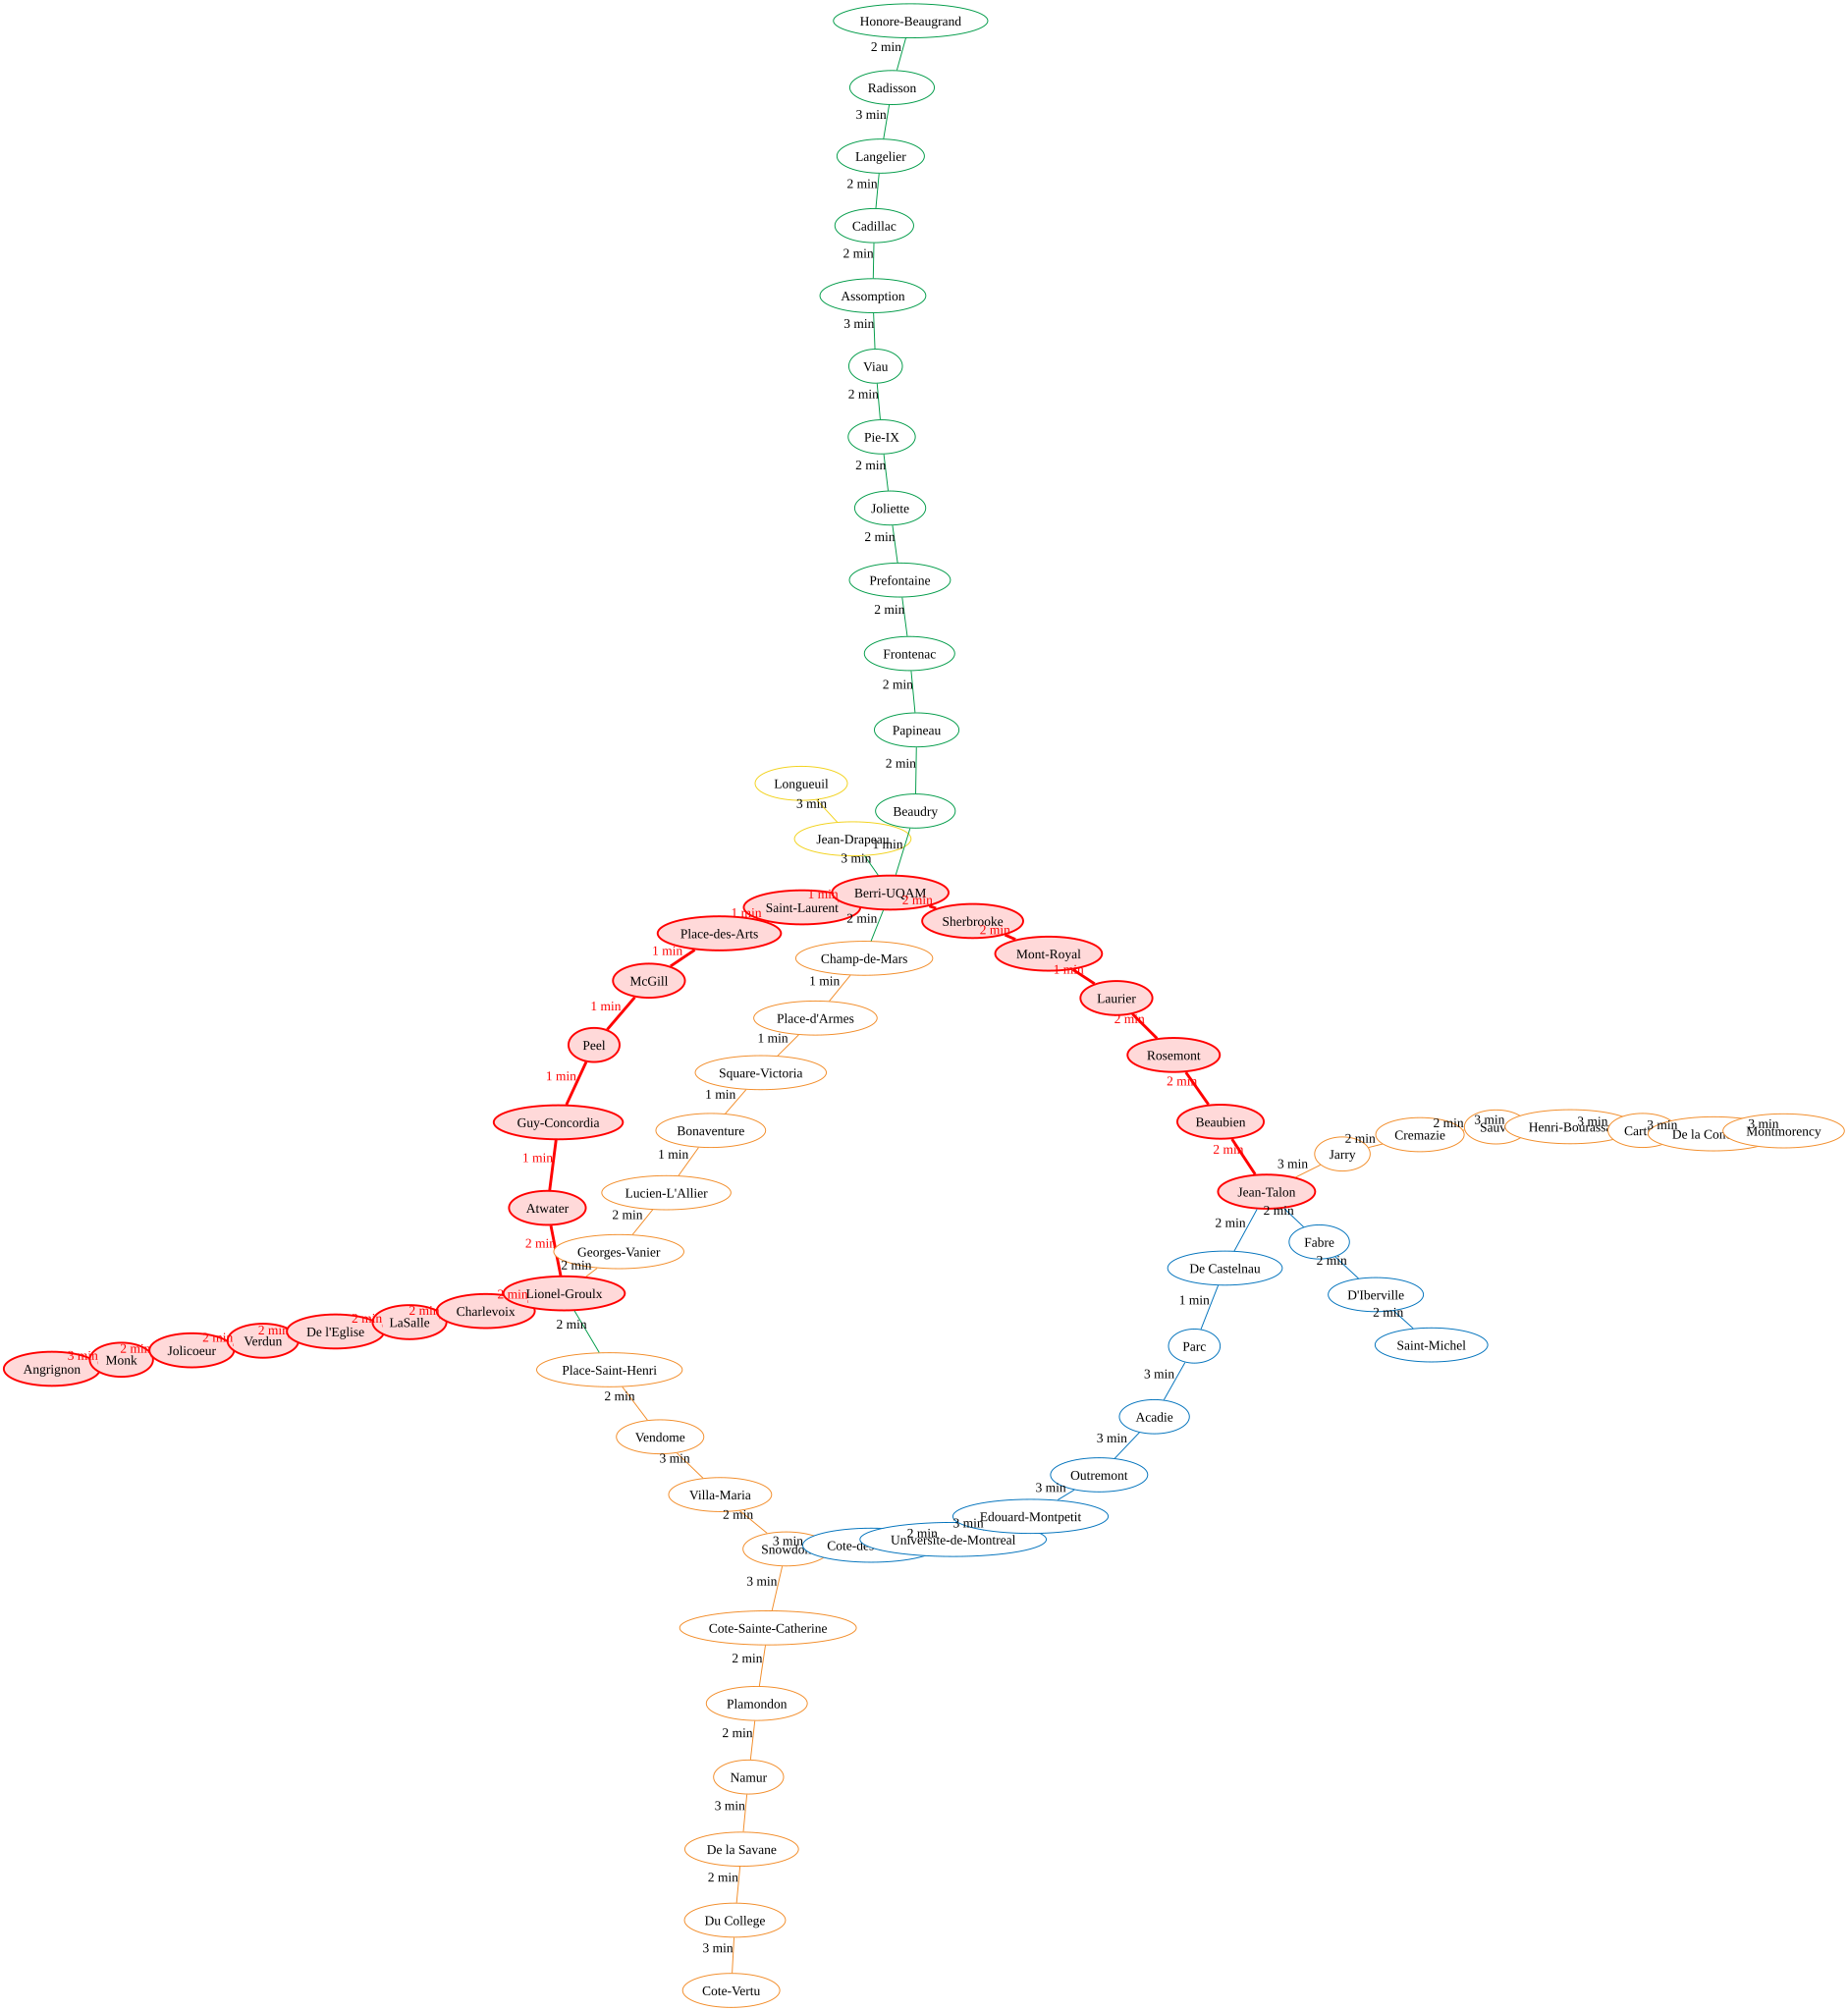

In [68]:
# Q5.2

from graphviz import Graph

depart = "Angrignon"
arrivee = "Jean-Talon"

distance, precedent = dijkstra(reseau, depart)
route = chemin(precedent, depart, arrivee)

graphe = Graph("Metro_Montreal", engine="neato")

couleurs_lignes = {
    "orange": "#F28C28",
    "verte": "#009B48",
    "bleue": "#0072BC",
    "jaune": "#F2D21B"
}

# Dessiner les stations
for station in reseau:
    ligne = infos_station[station]["ligne"]

    if station in route:
        graphe.node(
            station,
            style="filled",
            fillcolor="#ffd9d9",
            color="red",
            penwidth="2"
        )
    else:
        graphe.node(
            station,
            style="filled",
            fillcolor="white",
            color=couleurs_lignes[ligne]
        )

# Dessiner les connexions
for station in reseau:
    for voisin, minutes in reseau[station]:
        if station < voisin:
            est_sur_chemin = (
                station in route
                and voisin in route
                and abs(route.index(station) - route.index(voisin)) == 1
            )

            if est_sur_chemin:
                graphe.edge(
                    station,
                    voisin,
                    label=f"{minutes} min",
                    color="red",
                    penwidth="3",
                    fontcolor="red"
                )
            else:
                ligne = infos_station[station]["ligne"]
                graphe.edge(
                    station,
                    voisin,
                    label=f"{minutes} min",
                    color=couleurs_lignes[ligne],
                    fontcolor="black"
                )

graphe

> **Observation — obligatoire.** Décrivez ce que votre dessin rend visible et que la liste de stations ne montrait pas.
>
1. **La structure du réseau** : Le graphe permet de voir que le réseau contient des cycles (les deux cycles observés à la Q2.1), alors qu’une liste de stations présente une structure linéaire et ne permet pas de les visualiser.

2. **Les changements de ligne** : Le trajet suit d’abord la ligne verte, puis passe à la ligne orange. Les points de correspondance sont Lionel-Groulx et Berri-UQAM. Dans une liste, les correspondances apparaissent simplement comme des noms de stations qui se suivent, tandis que le graphe permet de voir les changements de couleur entre les lignes.

3. **Les trajets différents de BFS et de Dijkstra** : Le trajet de BFS, d’une durée de 44 minutes, passe par la ligne bleue. Sur le graphe, les tronçons de cette ligne portent souvent des étiquettes de 3 minutes, ce qui permet de comprendre pourquoi ce trajet est plus long en durée. C’est une preuve visuelle que le trajet comportant moins d’arrêts n’est pas nécessairement le plus rapide.

4. **La répartition des durées** : Les étiquettes permettent de voir quels tronçons durent 1 minute et lesquels durent 3 minutes, alors qu’une simple liste ne donne que les noms des stations.

---
## Partie 6 — Construire un tableau de données

Un modèle a besoin d'un **tableau** : une ligne par exemple, une colonne par
**donnée**, et une colonne à part pour l'**étiquette**.

Ici, **un exemple = une station**, et l'étiquette est sa **ligne**. Les données,
vous les fabriquez avec **votre propre travail des parties 3 et 4**.

On laisse de côté les stations de la ligne jaune : il y en a trop peu.

**Q6.1** — Pour chaque station retenue, fabriquez la liste de ses mesures :

1. son nombre de voisins ;
2. la durée moyenne de ses tronçons ;
3. la durée de son plus long tronçon ;
4. le nombre d'**arrêts** qui la séparent d'un **repère** *(votre BFS)* ;
5. le nombre de **minutes** qui l'en séparent *(votre Dijkstra)*.

Écrivez `mesures(station, nb_reperes)` de façon à pouvoir ajouter des repères
ensuite, et construisez `X_1repere` ainsi que `y`.

In [131]:
REPERES = ["Berri-UQAM", "Snowdon", "Honore-Beaugrand"]

stations_retenues = [s for s in sorted(reseau) if infos_station[s]["ligne"] != "jaune"]
y = [infos_station[s]["ligne"] for s in stations_retenues]
print(len(stations_retenues), "stations retenues")

# Q6.1

# Calculer BFS et Dijkstra une seule fois par repère
DISTANCES_BFS = {}
DISTANCES_DIJKSTRA = {}

for repere in REPERES:
    DISTANCES_BFS[repere], _ = bfs(reseau, repere)
    DISTANCES_DIJKSTRA[repere], _ = dijkstra(reseau, repere)


def mesures(station, nb_reperes):
    # 1. Nombre de voisins
    nb_voisins = len(reseau[station])

    # 2. Durée moyenne des tronçons
    durees = [minutes for voisin, minutes in reseau[station]]
    duree_moyenne = (
        sum(durees) / len(durees) if durees else 0
    )

    # 3. Durée du tronçon le plus long
    duree_max = max(durees) if durees else 0

    # Trois caractéristiques de base
    caracteristiques = [
        nb_voisins,
        duree_moyenne,
        duree_max
    ]

    # Deux caractéristiques par repère :
    # nombre d'arrêts (BFS) et durée en minutes (Dijkstra)
    for repere in REPERES[:nb_reperes]:
        nb_arrets = DISTANCES_BFS[repere].get(station, 9999)
        nb_minutes = DISTANCES_DIJKSTRA[repere].get(station, 9999)

        caracteristiques.extend([nb_arrets, nb_minutes])

    return caracteristiques



66 stations retenues


> **Observation — obligatoire.** Lesquelles de vos cinq mesures viennent des fichiers fournis, et lesquelles viennent de votre propre code ? Qui a choisi les repères ?
>
> Les trois premières mesures (nombre de voisins, durée moyenne et durée maximale des tronçons) viennent directement des fichiers fournis : je les calcule à partir des liens de `metro_montreal.csv`, sans algorithme de parcours. Les deux dernières mesures, le nombre d'arrêts et le nombre de minutes qui séparent une station d'un repère, viennent de mon propre code : le nombre d'arrêts est calculé par mon BFS et le nombre de minutes par mon Dijkstra. Les repères (Berri-UQAM, Snowdon et Honoré-Beaugrand) n'ont pas été choisis par moi : ils sont donnés par l'énoncé.
>
> Comme l'énoncé demande d'écrire `mesures(station, nb_reperes)` de façon à pouvoir ajouter des repères ensuite, j'avais d'abord pensé calculer, pour les mesures 4 et 5, la moyenne des distances depuis les différents repères. Cela permettait d'augmenter le nombre de repères sans changer la taille du tableau. Mais j'ai remarqué qu'une moyenne peut masquer les différences entre les repères : deux stations très différentes (l'une proche du premier repère et loin du second, l'autre l'inverse) peuvent avoir la même moyenne. J'ai posé la question à mon enseignant, qui m'a confirmé qu'il vaut mieux conserver les distances de chaque repère séparément. J'ai donc ajouté, pour chaque repère, deux colonnes : le nombre d'arrêts (BFS) et le nombre de minutes (Dijkstra). Le tableau a ainsi 3 colonnes fixes plus 2 colonnes par repère, soit 5, 7 puis 9 colonnes avec 1, 2 puis 3 repères. L'étiquette (la ligne) reste à part et n'est pas comptée. Pour que le calcul reste efficace, je lance le BFS et le Dijkstra une seule fois par repère, avant de parcourir les stations, puis `mesures` ne fait que lire ces résultats.
>
> Cette organisation a une conséquence : les trois premières mesures décrivent seulement l'environnement immédiat d'une station, alors que les deux dernières indiquent sa position dans le réseau. Ces dernières dépendent aussi de la justesse de mon BFS et de mon Dijkstra : si l'un des deux contenait une erreur, une grande partie des colonnes serait fausse sans que le modèle le signale.

**Q6.2** — Comptez combien de stations portent chaque étiquette, et déduisez-en la
note qu'obtiendrait un modèle qui répondrait **toujours la même chose**.

In [73]:
# Q6.2

from collections import Counter

comptage = Counter(y)
nombre_total = len(y)

print("Nombre total de stations :", nombre_total)

for ligne, nombre in comptage.items():
    pourcentage = nombre / nombre_total * 100
    print(f"Ligne {ligne} : {nombre} stations ({pourcentage:.2f} %)")

ligne_majoritaire = comptage.most_common(1)[0][0]
nombre_majoritaire = comptage.most_common(1)[0][1]

pourcentage_reference = nombre_majoritaire / nombre_total * 100

print("\nLigne majoritaire :", ligne_majoritaire)
print("Nombre de stations de cette ligne :", nombre_majoritaire)
print(f"Précision de référence : {pourcentage_reference:.2f} %")

Nombre total de stations : 66
Ligne bleue : 10 stations (15.15 %)
Ligne verte : 27 stations (40.91 %)
Ligne orange : 29 stations (43.94 %)

Ligne majoritaire : orange
Nombre de stations de cette ligne : 29
Précision de référence : 43.94 %


> **Observation — obligatoire.** Notez ce pourcentage. C'est la barre que votre modèle devra dépasser pour servir à quelque chose.
>
> *La ligne orange est la plus représentée, avec 29 stations sur 66, soit 43,94 %. Un modèle qui prédit toujours la ligne orange obtiendrait donc une précision de référence de 43,94 %, sans utiliser les caractéristiques des stations. Notre modèle devra dépasser ce pourcentage pour démontrer qu’il apprend réellement des relations entre les mesures des stations et leur ligne.*

## Partie 7 — Entraîner un modèle, et le noter honnêtement

**Q7.1** — Coupez en deux paquets (70 / 30), entraînez un `DecisionTreeClassifier`,
et affichez **deux** notes : sur les stations apprises, et sur les stations jamais
vues.

In [149]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Q7.1

# Construire la matrice des caractéristiques avec 1 repère
nb_reperes = 1

X = [
    mesures(station, nb_reperes)
    for station in stations_retenues
]

print("Nombre de stations :", len(X))
print("Nombre de caractéristiques :", len(X[0]))

# Diviser les données en deux ensembles (70 / 30)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0,
    stratify=y
)

# Entraîner le modèle
modele = DecisionTreeClassifier(random_state=0)
modele.fit(X_train, y_train)

# Calculer les deux précisions
precision_entrainement = modele.score(X_train, y_train)
precision_test = modele.score(X_test, y_test)

print(f"Précision sur les stations apprises : {precision_entrainement:.2%}")
print(f"Précision sur les stations jamais vues : {precision_test:.2%}")


Nombre de stations : 66
Nombre de caractéristiques : 5
Précision sur les stations apprises : 93.48%
Précision sur les stations jamais vues : 25.00%


> **Observation — obligatoire.** Vos deux notes sont très différentes. Comment s'appelle ce phénomène, et laquelle des deux est honnête ?
>
> Les résultats de la Q7.1 montrent que l’arbre de décision fonctionne très bien sur les données d’entraînement, mais qu’il obtient de mauvais résultats sur les données de test, avec une précision même inférieure à la précision de référence de 43,94 %. Cela signifie qu’avec les caractéristiques basées sur un seul repère, le modèle ne parvient pas encore à bien généraliser.Premièrement, il pourrait y avoir du surapprentissage *surapprentissage*. La précision sur les données d’entraînement est de 93,48 %, alors qu’elle n’est que de 25 % sur les données de test. 
> Un écart aussi important indique que le modèle obtient de très bons résultats sur les données d’entraînement, mais qu’il a du mal à s’appliquer à des stations qu’il n’a jamais vues. Ce phénomène est compatible avec un risque de surapprentissage.
> Additionalment, les informations de position fournies par un seul repère pourraient être insuffisantes.
> Le modèle utilise actuellement cinq caractéristiques, dont deux distances calculées à partir d’un même repère. Ces caractéristiques pourraient ne pas suffire à distinguer les stations des différentes lignes. L’utilisation de deux ou trois repères permettra de vérifier si l’ajout d’informations de position peut améliorer les résultats, sans toutefois garantir une augmentation de la précision.

**Q7.2** — Refaites la même chose avec **2** puis **3** repères. Affichez les trois
notes côte à côte.

In [144]:
# Q7.2 — Comparer 1, 2 et 3 repères

resultats = []

for nb_reperes in [1, 2, 3]:
    # Construire la matrice des caractéristiques
    X = [
        mesures(station, nb_reperes)
        for station in stations_retenues
    ]

    # Diviser les données en deux ensembles (70 / 30)
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=0,
        stratify=y
    )

    # Entraîner le modèle
    modele = DecisionTreeClassifier(random_state=0)
    modele.fit(X_train, y_train)

    # Calculer les deux précisions
    precision_entrainement = modele.score(X_train, y_train)
    precision_test = modele.score(X_test, y_test)

    resultats.append({
        "Nombre de repères": nb_reperes,
        "Nombre de caractéristiques": len(X[0]),
        "Précision entraînement": precision_entrainement,
        "Précision test": precision_test
    })

# Afficher les trois résultats côte à côte
print(f"{'Repères':<12}{'Caractéristiques':<20}"
      f"{'Entraînement':<18}{'Test':<12}")

for resultat in resultats:
    print(
        f"{resultat['Nombre de repères']:<12}"
        f"{resultat['Nombre de caractéristiques']:<20}"
        f"{resultat['Précision entraînement']:.2%}{'':<12}"
        f"{resultat['Précision test']:.2%}"
    )


Repères     Caractéristiques    Entraînement      Test        
1           5                   93.48%            25.00%
2           7                   100.00%            35.00%
3           9                   100.00%            60.00%


In [155]:
# Q7.3 — Comparer un arbre seul et une forêt aléatoire

import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Meilleures mesures : 3 repères (9 colonnes)
X = [mesures(station, 3) for station in stations_retenues]
y = [infos_station[station]["ligne"] for station in stations_retenues]
print("sklearn", sklearn.__version__, "|", len(X), "stations,", len(X[0]), "colonnes")

notes_arbre = []
notes_foret = []

for graine in range(5):
    # Le MÊME entier sert au découpage ET au modèle
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=graine, stratify=y)

    arbre = DecisionTreeClassifier(random_state=graine)
    arbre.fit(X_train, y_train)
    notes_arbre.append(arbre.score(X_test, y_test))

    foret = RandomForestClassifier(random_state=graine)
    foret.fit(X_train, y_train)
    notes_foret.append(foret.score(X_test, y_test))

def afficher_resultats(nom, notes):
    print(f"\n{nom}")
    print("Cinq notes :", [f"{n:.0%}" for n in notes])
    print(f"Moyenne : {np.mean(notes):.1%}")
    print(f"Écart (max - min) : {max(notes) - min(notes):.1%}")

afficher_resultats("Arbre de décision", notes_arbre)
afficher_resultats("Forêt aléatoire", notes_foret)

sklearn 1.9.1 | 66 stations, 9 colonnes

Arbre de décision
Cinq notes : ['60%', '70%', '55%', '60%', '60%']
Moyenne : 61.0%
Écart (max - min) : 15.0%

Forêt aléatoire
Cinq notes : ['55%', '70%', '65%', '50%', '55%']
Moyenne : 59.0%
Écart (max - min) : 20.0%


> **Observation — obligatoire.** Qu'est-ce qui change, et pourquoi un seul repère ne suffisait-il pas ? Pensez à deux stations situées de part et d'autre du repère.
>
>
> Avec un seul repère, la note d'entraînement est de 93,48 % et la note de test de seulement 25 %. Avec deux repères, on passe à 100 % et 35 %, puis avec trois repères à 100 % et 60 %. Ce qui change, c'est donc surtout la note sur les stations jamais vues.
>
> Un repère ne donne qu'une distance : il dit à quelle distance une station se trouve de Berri-UQAM, mais pas de quel côté. Deux stations situées de part et d'autre du repère, à la même distance, ont donc exactement les mêmes mesures. C'est le cas de Beaubien (ligne orange) et de Joliette (ligne verte), toutes deux à 5 arrêts et 9 minutes de Berri-UQAM, ou de Rosemont (orange) et de Préfontaine (verte), à 4 arrêts et 7 minutes. L'arbre ne peut pas les séparer : c'est pourquoi sa note d'entraînement n'atteint pas 100 %, et sa note de test (25 %) est même inférieure à la référence de 45 % sur le paquet de test.
>
> Un deuxième repère (Snowdon) donne à ces stations des distances différentes, ce qui permet à l'arbre de les distinguer : la note d'entraînement monte à 100 % et la note de test à 35 %. Un troisième repère (Honoré-Beaugrand) ajoute une information de position supplémentaire, et la note de test atteint 60 %. C'est comme une triangulation : un seul point de repère ne donne qu'un cercle de positions possibles, plusieurs repères permettent de situer la station.
>
> La note d'entraînement reste à 100 % entre deux et trois repères, alors que la note de test augmente. L'écart passe de 68,48 points (un repère) à 65 points (deux repères), puis à 40 points (trois repères). L'écart diminue donc, mais surtout parce que la note de test monte, et non parce que le modèle mémorise moins : il récite encore tous ses exemples d'entraînement. Un écart de 40 points reste important.
>
> Le paquet de test ne contient que 20 stations, donc une seule station vaut 5 points. Passer de 35 % à 60 % correspond à cinq stations de plus bien classées, ce qui peut dépendre en partie du découpage. La note de 60 % dépasse la référence (45 % sur le test), mais pas de beaucoup. Je conclus donc qu'ajouter des repères aide nettement entre un et deux repères, et que l'amélioration suivante est plus incertaine ; la partie Q7.3 permettra de vérifier la stabilité des notes.

**Q7.3** — Sur vos meilleures mesures, comparez un **arbre seul** à une **forêt
aléatoire**. Relancez chacun avec `random_state` valant 0, 1, 2, 3 puis 4, et
affichez pour chaque modèle ses cinq notes, leur **moyenne** et l'**écart** entre la
plus haute et la plus basse.

In [156]:
# Q7.3 — Comparer un arbre seul et une forêt aléatoire

import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Meilleures mesures : 3 repères (9 colonnes)
X = [mesures(station, 3) for station in stations_retenues]
y = [infos_station[station]["ligne"] for station in stations_retenues]
print("sklearn", sklearn.__version__, "|", len(X), "stations,", len(X[0]), "colonnes")

notes_arbre = []
notes_foret = []

for graine in range(5):
    # Le MÊME entier sert au découpage ET au modèle
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=graine, stratify=y)

    arbre = DecisionTreeClassifier(random_state=graine)
    arbre.fit(X_train, y_train)
    notes_arbre.append(arbre.score(X_test, y_test))

    foret = RandomForestClassifier(random_state=graine)
    foret.fit(X_train, y_train)
    notes_foret.append(foret.score(X_test, y_test))

def afficher_resultats(nom, notes):
    print(f"\n{nom}")
    print("Cinq notes :", [f"{n:.0%}" for n in notes])
    print(f"Moyenne : {np.mean(notes):.1%}")
    print(f"Écart (max - min) : {max(notes) - min(notes):.1%}")

afficher_resultats("Arbre de décision", notes_arbre)
afficher_resultats("Forêt aléatoire", notes_foret)

sklearn 1.9.1 | 66 stations, 9 colonnes

Arbre de décision
Cinq notes : ['60%', '70%', '55%', '60%', '60%']
Moyenne : 61.0%
Écart (max - min) : 15.0%

Forêt aléatoire
Cinq notes : ['55%', '70%', '65%', '50%', '55%']
Moyenne : 59.0%
Écart (max - min) : 20.0%


> **Observation — obligatoire.** La forêt vous a-t-elle aidés ? Appuyez-vous sur la moyenne ET sur l'écart, puis proposez une explication liée au nombre d'exemples dont vous disposez.
>
> Avec trois repères, l'arbre seul obtient sur les stations jamais vues les notes 60 %, 70 %, 55 %, 60 % et 60 %, soit une moyenne de 61 % et un écart de 15 points entre la plus haute et la plus basse. La forêt aléatoire obtient 55 %, 70 %, 65 %, 50 % et 55 %, soit une moyenne de 59 % et un écart de 20 points. La forêt ne nous a donc pas aidés : sa moyenne est légèrement plus basse que celle de l'arbre (2 points, moins que la valeur d'une seule station du paquet de test), et ses notes ne sont pas plus stables, puisque son écart est même plus grand.
>
> Cette différence est trop petite pour dire que l'un des deux modèles est meilleur. Avec 66 stations, le paquet de test n'en contient que 20, et une seule station vaut 5 points : un écart de 15 ou 20 points correspond à seulement trois ou quatre stations de plus ou de moins bien classées. Ces écarts montrent surtout que la note dépend beaucoup du découpage choisi, et qu'une seule note, comme les 60 % obtenus plus haut avec `random_state=0`, ne prouve pas grand-chose. Les cinq notes, avec leur moyenne et leur écart, sont donc plus fiables qu'un seul essai.
>
> Une forêt aléatoire réduit en général le surapprentissage en faisant la moyenne de plusieurs arbres entraînés sur des échantillons différents. Mais ce moyennage n'aide que si les arbres font des erreurs différentes et si les données sont assez nombreuses. Ici, nous n'avons que 46 stations pour l'entraînement, dont seulement 10 stations de la ligne bleue, et certaines stations sont difficiles à distinguer à partir des seules mesures de distance. Les arbres de la forêt font donc à peu près les mêmes erreurs, et la forêt ne peut pas faire mieux que l'arbre. Pour réellement améliorer le modèle, il faudrait surtout davantage de stations ou de meilleures mesures, et non un modèle plus complexe.

> Note: Dans cette question, j’ai utilisé la même valeur pour les deux paramètres `random_state`.
> Le `random_state` de `train_test_split` détermine quelles stations sont placées dans l’ensemble de test. Comme cet ensemble contient seulement une vingtaine de stations, c’est la principale source de variation des résultats.
>Le `random_state` du modèle influence surtout la forêt aléatoire. Avec un arbre de décision seul, les résultats varient généralement très peu. Si on ne changeait que le `random_state` du modèle, on obtiendrait souvent cinq fois la même note.
> En utilisant la même valeur pour les deux paramètres `random_state`, je m’assure que l’arbre de décision et la forêt aléatoire sont évalués sur les mêmes découpages des données, ce qui permet une comparaison équitable.

---
## Partie 8 — Vos conclusions

Répondez en Markdown, **en phrases complètes, en français**. Comptez deux ou trois
phrases par question, et **citez vos propres chiffres**.

**Sur le réseau**

1. Le réseau est-il un **arbre** ? Justifiez avec le nombre de stations et de liens.
2. Quelle station est la mieux connectée, et **pourquoi** celle-là ?
3. Sur vos trois paires, le BFS et Dijkstra donnent-ils souvent la même réponse ?
   Reliez votre réponse au décompte des durées.
4. Décrivez **une** paire où ils diffèrent, et expliquez ce que chacun a optimisé.

**Sur le modèle**

5. Avec un seul repère, quelle note obtenez-vous, et comment se compare-t-elle au
   modèle qui répond toujours la même chose ? Qu'est-ce que ça vous apprend ?
6. Qu'est-ce qui change avec 2 puis 3 repères, et **pourquoi** ?
7. Pourquoi la note sur les stations jamais vues est-elle la seule honnête ?
8. La forêt aléatoire vous a-t-elle aidés ? Appuyez-vous sur les cinq notes et sur
   l'écart.

**Sur l'ensemble**

9. Vos données de la partie 6 viennent de vos propres fonctions. Quel risque cela
   pose-t-il si votre BFS ou votre Dijkstra contient une erreur ?
10. Nommez **une** limite de nos données par rapport au vrai métro, et **une**
    mesure supplémentaire que vous auriez aimé avoir pour le modèle.

### Vos réponses

*(remplacez ce texte)*

1. Non, le réseau n'est pas un arbre. Un arbre à 68 stations aurait exactement 67 liens, or nous en avons 69 : les deux liens en trop créent deux cycles indépendants (69 − 68 + 1 = 2), par exemple entre Lionel-Groulx et Berri-UQAM, qu'on peut relier par la ligne verte ou par la ligne orange.

2. La station la mieux connectée est Berri-UQAM, avec 5 voisins. C'est le point de rencontre de trois lignes (orange, verte et jaune), alors qu'une station ordinaire n'a que 2 voisins et un terminus 1 seul.

3. Les tronçons de 2 minutes sont les plus nombreux, avec 37 tronçons sur 69, soit environ 53,6 % du réseau. Les tronçons de 3 minutes (19, soit 27,5 %) et de 1 minute (13, soit 18,8 %) sont moins fréquents. La durée de 2 minutes est donc la durée dominante, et les durées sont toutes proches les unes des autres.

4. Pour Angrignon → Jean-Talon, le BFS donne 19 arrêts mais 44 minutes, alors que Dijkstra donne 20 arrêts mais 34 minutes. Le BFS a minimisé le nombre d’arrêts, en passant par la ligne bleue dont les tronçons durent plus longtemps, tandis que Dijkstra a minimisé la durée totale, en passant par le centre.

5. Avec un seul repère, j’obtiens 93,48 % sur les stations apprises mais seulement 25 % sur les stations jamais vues, ce qui est inférieur au modèle qui répond toujours «orange» (43,94 % sur l’ensemble, 45 % sur le paquet de test). Cela m’apprend qu’une seule distance ne suffit pas : deux stations situées de part et d’autre du repère, à la même distance (par exemple Beaubien et Joliette), ont les mêmes mesures et l’arbre ne peut pas les distinguer.

6. Avec deux repères, la note de test passe à 35 %, puis à 60 % avec trois, alors que la note d’entraînement atteint 100 %. Chaque repère supplémentaire ajoute une information de position, un peu comme une triangulation, ce qui sépare les stations qui se ressemblaient; mais comme le paquet de test ne compte que 20 stations (une station vaut 5 points), le gain entre deux et trois repères est moins sûr que celui entre un et deux.

7. La note d’entraînement mesure ce que le modèle a déjà vu: il peut en grande partie la mémoriser, comme le montrent les 100 % de la question 7.2. Seule la note sur les stations jamais vues indique comment il se comportera sur de nouvelles données, ce qui est le but d’un modèle.

8. La forêt aléatoire ne nous a pas aidés. Sur cinq essais, l’arbre seul obtient en moyenne 61 % avec un écart de 15 points entre la meilleure et la pire note, et la forêt 59 % avec un écart de 20 points : la différence de moyenne (2 points) est inférieure à la valeur d’une seule station, et les notes ne sont pas plus stables. Avec seulement 66 stations, il n’y a pas assez d’exemples pour que la moyenne de plusieurs arbres change le résultat.

9. Les mesures 4 et 5 viennent de mon propre BFS et de mon propre Dijkstra. Si l’un d’eux contenait une erreur：
a. Les caractéristiques 4 et 5 de la partie 6 (le nombre d’arrêts et la durée en minutes depuis un repère) proviennent directement des algorithmes BFS et Dijkstra que vous avez programmés.
b. Si ces fonctions contiennent des erreurs, les valeurs de ces deux colonnes seront incorrectes. Pourtant, le code ne déclenchera pas nécessairement d’erreur : le modèle pourra quand même être entraîné et produire des scores.
c. Les résultats peuvent donc sembler normaux sans refléter fidèlement le véritable réseau de métro. Le modèle apprend des régularités à partir de données erronées, et les conclusions tirées, par exemple que « trois repères donnent de meilleurs résultats », peuvent ne pas être fiables.
d. Il est donc nécessaire de vérifier ces fonctions au lieu de supposer qu’elles sont correctes simplement parce que le code s’exécute sans erreur.

10. Une limite de nos données est qu’elles ne contiennent ni le temps de correspondance ni le temps d’attente: le modèle de la question 4.3 considère qu’il est gratuit de changer de ligne, alors que le trajet le plus rapide selon Dijkstra (28 minutes, deux correspondances) n’est que 2 minutes plus court qu’un trajet sur la seule ligne orange (30 minutes, sans correspondance). Une mesure supplémentaire que j’aurais aimé avoir pour le modèle est la position géographique de chaque station (latitude et longitude): elle indiquerait de quel côté d’un repère se trouve une station, ce qui permettrait de distinguer des stations comme Beaubien et Joliette, dont les mesures sont identiques avec un seul repère.

---
## Déclaration d'utilisation de l'intelligence artificielle

**Obligatoire, même si vous n'en avez pas utilisé.** Une déclaration absente ou
fausse vaut **0 pour l'ensemble du TP**.

L'IA est permise **pour apprendre**, pas pour produire votre travail. Relisez les
règles de l'énoncé avant de remplir cette section.

**Avez-vous utilisé un outil d'IA ?** oui

**Si oui, remplissez le tableau :**

| Outil | Pour quelle question | Ce que vous lui avez demandé | Lien de partage de la conversation |
|---|---|---|---|
|Chatgpt et Claude | depuis Q5.2  |  J’ai consulté une IA pour mieux comprendre les énoncés, discuter des points que je ne comprenais pas et comparer les conseils de différents agents. J’ai ensuite arrêté ma démarche en tenant compte des réponses de mon enseignant. J’ai rédigé mes observations avec mes propres mots, puis j’ai demandé à l’IA de les corriger et d’améliorer la formulation.| TP1_questions_reponses.md |
|  |  |  |  |

**Confirmez, en écrivant « oui » :**

- Je n'ai **pas** collé l'énoncé du TP, en tout ou en partie, dans une conversation
  avec une IA. → _Oui____
- Je n'ai **pas** collé le contenu des fichiers de données. → __Oui___
- Je comprends chaque ligne de code que je remets et je peux l'expliquer à l'oral.
  → __Oui___

---

**Qui a fait quoi :** J'ai réalisé ce TP seule, sans coéquipier. J'ai discuté de la
question 6.1 avec Khaoula (une autre étudiante du cours) pour comparer nos façons de
comprendre l'énoncé; le code et les observations de mon carnet sont rédigés par moi.

---
## Avant de remettre

**Vingt points du TP ne portent pas sur vos réponses** : dix sur la tenue de ce
carnet, dix sur votre usage de Git. Relisez les sections 3 et 4 de l'énoncé avant de
déposer votre travail.

**Le carnet.** Faites **Kernel → Redémarrer et tout exécuter** en dernier, et
vérifiez qu'aucune cellule ne produit d'erreur. Puis relisez-le comme si vous ne
l'aviez pas écrit : est-ce qu'on s'y retrouve ? Est-ce que chaque nombre affiché
s'explique sans aller lire le code ? Reste-t-il des cellules d'essai, des variables
au nom obscur, des observations expédiées ? Le français est-il relu ?

**Le dépôt.** Le nom de votre branche et vos messages de commit suivent la
convention vue en cours. Votre historique doit montrer un travail construit au fil du
temps — et, si vous êtes deux, la contribution des deux.

**L'identification.** Nom, coéquipier et groupe en première cellule, « qui a fait
quoi » à la fin, déclaration d'IA remplie même si la réponse est « non », et le
dossier `donnees/` à côté du carnet.

---

*Ensuite : `Publish branch`, `Create Pull Request`, fusion dans `main`, et le lien du
dépôt sur Omnivox.*